<a href="https://www.kaggle.com/code/flixrojas/air-quality-data-filtering?scriptVersionId=312946398" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [13]:
import pandas as pd
from google.cloud import bigquery

client = bigquery.Client()
dataset_ref = client.dataset("epa_historical_air_quality", project="bigquery-public-data")
dataset = client.get_dataset(dataset_ref)

tables = list(client.list_tables(dataset))

print("Tables in the EPA dataset:")
for table in tables:
    print(table.table_id)

Using Kaggle's public dataset BigQuery integration.
Tables in the EPA dataset:
air_quality_annual_summary
co_daily_summary
co_hourly_summary
hap_daily_summary
hap_hourly_summary
lead_daily_summary
no2_daily_summary
no2_hourly_summary
nonoxnoy_daily_summary
nonoxnoy_hourly_summary
o3_daily_summary
o3_hourly_summary
pm10_daily_summary
pm10_hourly_summary
pm25_frm_daily_summary
pm25_frm_hourly_summary
pm25_nonfrm_daily_summary
pm25_nonfrm_hourly_summary
pm25_speciation_daily_summary
pm25_speciation_hourly_summary
pressure_daily_summary
pressure_hourly_summary
rh_and_dp_daily_summary
rh_and_dp_hourly_summary
so2_daily_summary
so2_hourly_summary
temperature_daily_summary
temperature_hourly_summary
voc_daily_summary
voc_hourly_summary
wind_daily_summary
wind_hourly_summary


In [14]:
table_ref = dataset_ref.table("air_quality_annual_summary")
table = client.get_table(table_ref)

for schema_field in table.schema:
    print(f"{schema_field.name} - {schema_field.field_type}")

state_code - STRING
county_code - STRING
site_num - STRING
parameter_code - INTEGER
poc - INTEGER
latitude - FLOAT
longitude - FLOAT
datum - STRING
parameter_name - STRING
sample_duration - STRING
pollutant_standard - STRING
metric_used - STRING
method_name - STRING
year - INTEGER
units_of_measure - STRING
event_type - STRING
observation_count - INTEGER
observation_percent - FLOAT
completeness_indicator - STRING
valid_day_count - INTEGER
required_day_count - INTEGER
exceptional_data_count - INTEGER
null_data_count - INTEGER
primary_exceedance_count - INTEGER
secondary_exceedance_count - INTEGER
certification_indicator - STRING
num_obs_below_mdl - INTEGER
arithmetic_mean - FLOAT
arithmetic_standard_dev - FLOAT
first_max_value - FLOAT
first_max_datetime - TIMESTAMP
second_max_value - FLOAT
second_max_datetime - TIMESTAMP
third_max_value - FLOAT
third_max_datetime - TIMESTAMP
fourth_max_value - FLOAT
fourth_max_datetime - TIMESTAMP
first_max_non_overlapping_value - FLOAT
first_no_max_date

In [ ]:
# Extracting the arithmetic mean of particulates below 2.5
# these particulates stem from vehicle and building emissions
# that can be generated by burning, chemical reactions, dust storms
# they can also be secondarily generated in the atmosphere through chemical reactions

query = """
SELECT 
    date_local, 
    arithmetic_mean as pm25
FROM 
    `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary`
WHERE 
    state_name = 'California' 
    AND county_name = 'Los Angeles'
    AND date_local >= '2018-01-01' AND date_local <= '2025-12-31'
ORDER BY 
    date_local ASC
"""

query_job = client.query(query)
 
df = query_job.to_dataframe()

display(df.head())

I'm changing the format to pandas datetime just to make sure it is handled properly

I will also be printing the dataframe info to make sure I do not have to deal with empty or null values since it is a time series

In [ ]:
# reformatting the data and averaging county data measurements
df['date_local'] = pd.to_datetime(df['date_local'])

# date is now the index so we can query using a specified datetime
df.set_index('date_local', inplace=True)

print(df.info())

## Preprocessing
Since the data is a time series, we need to ensure that it is:
- Contiguous
- Sorted
- Free of missing values (done)

I will proceed to visualize the dataset to look for 
- Seasonality (repeating patterns)
- Trend (arrangement of datpoints following a pattern)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.plot(df.index, df['pm25'], label='Daily PM2.5', linewidth=1)
plt.title('Daily Average PM2.5 in LA (2018-2025)')
plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.legend()
plt.show()

That is how the overall data looks but there are two problems: 
- sample is too large, so I will reduce it to a random year to see if there might be seasonal changes (like summer wildfires)
- Datapoints from 2022 - 2023, 2023 - 2024 and 2024-2025 look suspiciously wrong 

First I will plot two years that don't look suspicious to see if there is seasonality or trend within them. I'll define a function to plot a range for this PDA.

In [ ]:
def plot_date_range(df, start_date, end_date, column='pm25'):
    date_range_subset = df.loc[pd.to_datetime(start_date):pd.to_datetime(end_date)]
    
    plt.figure(figsize=(15, 6))
    plt.plot(date_range_subset.index, date_range_subset[column], linewidth=1.5)
    
    plt.title(f'Daily Average PM2.5 in Los Angeles ({start_date} to {end_date})')
    plt.xlabel('Date')
    plt.ylabel('PM2.5 Concentration (µg/m³)')
    plt.tight_layout()
    plt.show()

plot_date_range(df, '2018-01-01','2018-12-31')

In [ ]:
plot_date_range(df, '2019-01-01','2019-12-31')

In [ ]:
plot_date_range(df, '2020-01-01','2020-12-31')

There seems to be some seasonality on the last months and the beginning months (probably due to increased electric consumption in winter) and an insane peak in July (fireworks due to July 4th)

I will now make boxplots for the seasons to make the visualization clearer

In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

def plot_seasonal_buckets(df, start_date, end_date, column='pm25'):
    subset = df.loc[start_date:end_date].copy()
    
    subset['season'] = subset.index.month.map(get_season)
    plt.figure(figsize=(10, 6))
    season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
    
    sns.boxplot(data=subset, x='season', y=column, order=season_order)
    
    plt.title(f'Seasonal PM2.5 Buckets in Los Angeles ({start_date} to {end_date})')
    plt.xlabel('Season')
    plt.ylabel('PM2.5 Concentration (µg/m³)')
    plt.tight_layout()
    plt.show()

plot_seasonal_buckets(df, '2018-01-01', '2018-12-31')

In [ ]:
# the following code was generated by Gemini 3.1 pro
# why? i needed a complex graph and I am not used to the seaborn package
# it is also just for EDA

# 1. Create a copy and extract the necessary categorical columns
df_subplots = df.copy()
df_subplots['year'] = df_subplots.index.year
df_subplots['season'] = df_subplots.index.month.map(get_season)

# 2. Define the logical order for the x-axis
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

# 3. Use catplot to generate the subplots
# 'col="year"' tells Seaborn to make a new subplot for each unique year
# 'col_wrap=3' limits the grid to 3 subplots per row before wrapping to the next line
g = sns.catplot(
    data=df_subplots, 
    x='season', 
    y='pm25', 
    col='year', 
    col_wrap=3, 
    kind='box', 
    order=season_order,
    height=4, 
    aspect=1.2,
    palette='Set2'
)

# 4. Format the titles and labels
g.set_axis_labels("Season", "PM2.5 Concentration (µg/m³)")
g.set_titles("Year: {col_name}")

# Add a main title to the entire figure (y=1.05 pushes it slightly above the subplots)
g.fig.suptitle("Seasonal Distribution of PM2.5 in Los Angeles (2018-2022)", y=1.05)

plt.show()

Years 2022 and onwards look incomplete, so I will only use the data from 2018-2021.

Also there is a clear indication that Winter has the largest variation and ranges for PM 2.5, so this set does possess seasonality (as well as in Autumn)!

## Data split
Since the data from 2022 seems to be incomplete, I will split the data using the classic 80 - 20 split from 2018 to 2021

In [ ]:
filtered_data = df.loc['2018-01-01':'2021-12-31']

training_fraction = 0.8

# index where the split happens
# int casting because it's supposed to be an idx
split_index = int(training_fraction * len(filtered_data))

train_data = filtered_data.iloc[:split_index]
test_data = filtered_data.iloc[split_index:]

Finally we rescale the data to go from 0.0 to 1.0 for training

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data[['pm25']])
test_scaled = scaler.transform(test_data[['pm25']])

## Second approximation
My goal is to determine PM2.5 presence in the air using the overall data from 2018-2021, due to some data gaps in 2023
I will do the same query but merging related data to wind and temperature as potentially predictive

I'll do a test query to see how many datapoints we are dealing with

In [ ]:
test_query = """
SELECT
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.date_local,
    pm.arithmetic_mean AS pm25_level,
    t.arithmetic_mean AS temperature,
    w.arithmetic_mean AS wind_speed
FROM
    `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary` AS pm
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.temperature_daily_summary` AS t
    ON pm.state_code = t.state_code
    AND pm.county_code = t.county_code
    AND pm.site_num = t.site_num
    AND pm.date_local = t.date_local
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.wind_daily_summary` AS w
    ON pm.state_code = w.state_code
    AND pm.county_code = w.county_code
    AND pm.site_num = w.site_num
    AND pm.date_local = w.date_local
WHERE
    -- only 2020
    pm.date_local >= '2020-01-01' 
    AND pm.date_local <= '2020-12-31'
    AND pm.state_code = '06' -- California
ORDER BY
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.date_local;
"""

query_job = client.query(test_query)
 
df_large_test = query_job.to_dataframe()

display(df_large_test.head())

In [ ]:
df_large_test.info()

## Nation-wide query
78434 datapoints is nice but I want a nationwide datasweep to determine how wind and temperature carry PM2.5

In [ ]:
nation_wide_query = """
SELECT
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.date_local,
    pm.time_local,
    pm.sample_measurement AS pm25_level,
    t.sample_measurement AS temperature,
    w.sample_measurement AS wind_speed
FROM
    `bigquery-public-data.epa_historical_air_quality.pm25_frm_hourly_summary` AS pm
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.temperature_hourly_summary` AS t
    ON pm.state_code = t.state_code
    AND pm.county_code = t.county_code
    AND pm.site_num = t.site_num
    AND pm.date_local = t.date_local
    AND pm.time_local = t.time_local
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.wind_hourly_summary` AS w
    ON pm.state_code = w.state_code
    AND pm.county_code = w.county_code
    AND pm.site_num = w.site_num
    AND pm.date_local = w.date_local
    AND pm.time_local = w.time_local
WHERE
    -- only 2020
    pm.date_local >= '2020-01-01' 
    AND pm.date_local <= '2020-12-31'
ORDER BY
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.time_local,
    pm.date_local;
"""
query_job = client.query(nation_wide_query)
 
usa_2020_aq_df = query_job.to_dataframe()

display(usa_2020_aq_df.head())

In [ ]:
usa_2020_aq_df.info()

In [ ]:
# convert to pandas format
usa_2020_aq_df['date_local'] = pd.to_datetime(usa_2020_aq_df['date_local'].astype(str))
usa_2020_aq_df['timestamp'] = pd.to_datetime(usa_2020_aq_df['date_local'].astype(str) + ' ' + usa_2020_aq_df['time_local'])

usa_2020_aq_df.info()

In [ ]:
# save to compressed parquet file for backup
usa_2020_aq_df.to_parquet('usa_2020_aq_df.parquet', engine='pyarrow')

In [ ]:
# make the same process for years 2018-2021

def save_aq_df_2018_2021():
    nation_wide_query = """
SELECT
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.date_local,
    pm.time_local,
    pm.sample_measurement AS pm25_level,
    t.sample_measurement AS temperature,
    w.sample_measurement AS wind_speed
FROM
    `bigquery-public-data.epa_historical_air_quality.pm25_frm_hourly_summary` AS pm
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.temperature_hourly_summary` AS t
    ON pm.state_code = t.state_code
    AND pm.county_code = t.county_code
    AND pm.site_num = t.site_num
    AND pm.date_local = t.date_local
    AND pm.time_local = t.time_local
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.wind_hourly_summary` AS w
    ON pm.state_code = w.state_code
    AND pm.county_code = w.county_code
    AND pm.site_num = w.site_num
    AND pm.date_local = w.date_local
    AND pm.time_local = w.time_local
WHERE
    pm.date_local >= '2018-01-01' 
    AND pm.date_local <= '2021-12-31'
ORDER BY
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.time_local,
    pm.date_local;
"""
    query_job = client.query(nation_wide_query)
    usa_2020_aq_df = query_job.to_dataframe()
    
    # convert to pandas format
    usa_2020_aq_df['date_local'] = pd.to_datetime(usa_2020_aq_df['date_local'].astype(str))
    usa_2020_aq_df['timestamp'] = pd.to_datetime(usa_2020_aq_df['date_local'].astype(str) + ' ' + usa_2020_aq_df['time_local'])
    usa_2020_aq_df.to_parquet('usa_2018_2021_aq_df.parquet', engine='pyarrow')

save_aq_df_2018_2021()

In [ ]:
backup_df = pd.read_parquet("/kaggle/working/usa_2018_2021_aq_df.parquet")

In [ ]:
# make the same process for years 2018-2021

def save_aq_df_2018_2021_geospatial():
    nation_wide_geoquery = """
SELECT
    pm.state_code,
    pm.county_code,
    pm.site_num,
    pm.latitude,
    pm.longitude,
    pm.date_local,
    pm.time_local,
    pm.sample_measurement AS pm25_level,
    t.sample_measurement AS temperature,
    w.sample_measurement AS wind_speed
FROM
    `bigquery-public-data.epa_historical_air_quality.pm25_frm_hourly_summary` AS pm
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.temperature_hourly_summary` AS t
    ON pm.state_code = t.state_code
    AND pm.county_code = t.county_code
    AND pm.site_num = t.site_num
    AND pm.date_local = t.date_local
    AND pm.time_local = t.time_local
INNER JOIN
    `bigquery-public-data.epa_historical_air_quality.wind_hourly_summary` AS w
    ON pm.state_code = w.state_code
    AND pm.county_code = w.county_code
    AND pm.site_num = w.site_num
    AND pm.date_local = w.date_local
    AND pm.time_local = w.time_local
WHERE
    pm.date_local >= '2018-01-01' 
    AND pm.date_local <= '2021-12-31'
ORDER BY
    pm.state_code,
    pm.county_code,
    pm.latitude,
    pm.longitude,
    pm.site_num,
    pm.time_local,
    pm.date_local;
"""
    query_job = client.query(nation_wide_geoquery)
    usa_2020_aq_df_geo = query_job.to_dataframe()
    
    # convert to pandas format
    usa_2020_aq_df_geo['date_local'] = pd.to_datetime(usa_2020_aq_df_geo['date_local'].astype(str))
    usa_2020_aq_df_geo['timestamp'] = pd.to_datetime(usa_2020_aq_df_geo['date_local'].astype(str) + ' ' + usa_2020_aq_df_geo['time_local'])
    usa_2020_aq_df_geo.to_parquet('usa_2018_2021_aq_df_geoquery.parquet', engine='pyarrow')

save_aq_df_2018_2021_geospatial()

## Calculate the new split on the time series
I'm using a random split to predict spatial values based on adjacent values

In [ ]:
import pandas as pd
backup_df = pd.read_parquet("/kaggle/input/datasets/flixrojas/usa-2018-2021-aq-df-geoquery-parquet")
backup_df.info()

## We rescale the data for fitting

On my original approach I was just trying to calculate PM25 without taking time into account. This was a mistake and upon review of the general literature, the preprocessing for spatio-temporal features was lacking.

## Cyclical encoding

In [ ]:
import numpy as np
import pandas as pd

day_of_year = backup_df['timestamp'].dt.dayofyear
hour_of_day = backup_df['timestamp'].dt.hour

DAYS_IN_YEAR = 365.2425 # leap year approximate
HOURS_IN_DAY = 24.0

backup_df['day_sin'] = np.sin(2 * np.pi * day_of_year / DAYS_IN_YEAR)
backup_df['day_cos'] = np.cos(2 * np.pi * day_of_year / DAYS_IN_YEAR)

backup_df['hour_sin'] = np.sin(2 * np.pi * hour_of_day / HOURS_IN_DAY)
backup_df['hour_cos'] = np.cos(2 * np.pi * hour_of_day / HOURS_IN_DAY)

## Features and target

In [ ]:
lstm_features = ['latitude', 'longitude', 'temperature', 'wind_speed', 'day_sin', 'day_cos', 'hour_sin', 'hour_cos']
target_col = 'pm25_level'

### LSTM sequences
I'll group the cyclical time data, grouping it in 7 days 

In [ ]:
def create_lstm_sequences(df, features, target, sequence_length=7):
    X_seq, y_seq = [], []

    # group by lat,lon pairs
    grouped = df.groupby(['latitude', 'longitude'])
    
    for _, group in grouped:
        group = group.sort_values('timestamp')
        
        feature_data = group[features].values
        target_data = group[target].values
        
        # create sliding windows
        for i in range(len(group) - sequence_length):
            X_seq.append(feature_data[i : i + sequence_length])
            # target PM2.5 level for the next timestep
            y_seq.append(target_data[i + sequence_length])
            
    return np.array(X_seq), np.array(y_seq)

sequence_length = 7
X_lstm, y_lstm = create_lstm_sequences(backup_df, lstm_features, target_col, sequence_length)

print(f"LSTM Input Shape: {X_lstm.shape}") # Should be (samples, 7, 8)
print(f"LSTM Target Shape: {y_lstm.shape}") # Should be (samples,)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_lstm_model(sequence_length, num_features):
    model = models.Sequential([
        # 3d input
        layers.Input(shape=(sequence_length, num_features)),
        
        layers.LSTM(64, return_sequences=False),
        layers.BatchNormalization(),
        
        # Standard Dense layers for final regression mapping
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        
        # continuous PM2.5 prediction
        layers.Dense(1)
    ])
    
    model.compile(optimizer='adam', 
                  loss='mse', 
                  metrics=['mae', 
                           tf.keras.metrics.RootMeanSquaredError(name='rmse'),
                           tf.keras.metrics.MeanAbsolutePercentageError(name='mape')]
                 )
    return model

lstm_model = build_lstm_model(
    sequence_length=X_lstm.shape[1], 
    num_features=X_lstm.shape[2]
)

lstm_model.summary()

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split

# 80-20 split
X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=1, shuffle=True
)

# lstm model 
checkpoint = ModelCheckpoint(
    filepath='pm25_lstm_model_checkpoint.keras', 
    monitor='val_loss',
    save_best_only=True,  
    mode='min',           
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_seq, 
    y_train_seq,
    epochs=40,
    batch_size=8192, 
    validation_data=(X_val_seq, y_val_seq),
    verbose=1,
    callbacks=[checkpoint, early_stop]
)

In [ ]:
import numpy as np
from datetime import datetime

def predict_pm25(model, scaler_x, scaler_y, latitude, longitude, target_date, temperature, wind_speed):
    day_of_year = target_date.timetuple().tm_yday
    hour_of_day = target_date.hour
    
    DAYS_IN_YEAR = 365.2425
    HOURS_IN_DAY = 24.0
    
    day_sin = np.sin(2 * np.pi * day_of_year / DAYS_IN_YEAR)
    day_cos = np.cos(2 * np.pi * day_of_year / DAYS_IN_YEAR)
    hour_sin = np.sin(2 * np.pi * hour_of_day / HOURS_IN_DAY)
    hour_cos = np.cos(2 * np.pi * hour_of_day / HOURS_IN_DAY)
    
    raw_input = np.array([[
        latitude, 
        longitude, 
        temperature, 
        wind_speed, 
        day_sin, 
        day_cos, 
        hour_sin, 
        hour_cos
    ]])

    scaled_input = scaler_x.transform(raw_input)
    scaled_prediction = model.predict(scaled_input, verbose=0)
    
    # Inverse transform the output to get the real PM2.5 concentration in µg/m³
    actual_prediction = scaler_y.inverse_transform(scaled_prediction)
    
    return actual_prediction[0][0]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

split_idx = int(len(backup_df) * 0.8)
train_df = backup_df.iloc[:split_idx].copy()
val_df = backup_df.iloc[split_idx:].copy()

# fit scalers strictly on the training data to prevent data leakage
train_df[lstm_features] = scaler_x.fit_transform(train_df[lstm_features])
train_df[[target_col]] = scaler_y.fit_transform(train_df[[target_col]])

# transform validation data using the fitted scalers
val_df[lstm_features] = scaler_x.transform(val_df[lstm_features])
val_df[[target_col]] = scaler_y.transform(val_df[[target_col]])

# generate 3D sequences separately to avoid cross-contamination
X_train_seq, y_train_seq = create_lstm_sequences(train_df, lstm_features, target_col)
X_val_seq, y_val_seq = create_lstm_sequences(val_df, lstm_features, target_col)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import load_model

loaded_lstm_model = load_model('/kaggle/input/models/flixrojas/first-lstm/keras/default/1/pm25_lstm_model_checkpoint_epoch_26.keras')

y_pred_seq_scaled = loaded_lstm_model.predict(X_val_seq)

# sequence generator outputs (samples,), but scaler_y expects (samples, 1)
y_val_seq_2d = y_val_seq.reshape(-1, 1)

# get actual PM2.5 levels (µg/m³)
y_pred_seq_actual = scaler_y.inverse_transform(y_pred_seq_scaled)
y_true_seq_actual = scaler_y.inverse_transform(y_val_seq_2d)

mae_lstm = mean_absolute_error(y_true_seq_actual, y_pred_seq_actual)
mse_lstm = mean_squared_error(y_true_seq_actual, y_pred_seq_actual)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(y_true_seq_actual, y_pred_seq_actual)

# 5. Display the results
print(f"LSTM Real-World MAE:  {mae_lstm:.2f} µg/m³")
print(f"LSTM Real-World MSE:  {mse_lstm:.2f} (µg/m³)²")
print(f"LSTM Real-World RMSE: {rmse_lstm:.2f} µg/m³")
print(f"LSTM R-squared (R2):  {r2_lstm:.4f}")

I forgot to load the re-scalers so now i have to do it all over again

In [17]:
import numpy as np
import pandas as pd

def predict_pm25_sequence(model, scaler_x, scaler_y, history_df):
    if len(history_df) != 7:
        raise ValueError(f"The model expects exactly 7 timesteps, but got {len(history_df)}.")
        
    df = history_df.copy()
    
    DAYS_IN_YEAR = 365.2425
    HOURS_IN_DAY = 24.0
    
    day_of_year = df['timestamp'].dt.dayofyear
    hour_of_day = df['timestamp'].dt.hour
    
    df['day_sin'] = np.sin(2 * np.pi * day_of_year / DAYS_IN_YEAR)
    df['day_cos'] = np.cos(2 * np.pi * day_of_year / DAYS_IN_YEAR)
    df['hour_sin'] = np.sin(2 * np.pi * hour_of_day / HOURS_IN_DAY)
    df['hour_cos'] = np.cos(2 * np.pi * hour_of_day / HOURS_IN_DAY)
    
    lstm_features = [
        'pm25_level', 'latitude', 'longitude', 'temperature', 'wind_speed', 
        'day_sin', 'day_cos', 'hour_sin', 'hour_cos'
    ]
    
    raw_input_2d = df[lstm_features].values
    
    scaled_input_2d = scaler_x.transform(raw_input_2d)
    
    lstm_input_3d = scaled_input_2d.reshape(1, 7, 9)
    
    scaled_prediction = model.predict(lstm_input_3d, verbose=0)
    
    actual_prediction = scaler_y.inverse_transform(scaled_prediction)
    
    return actual_prediction[0][0]

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib 

# 1. Load Data & Add Cyclical Features
backup_df = pd.read_parquet("/kaggle/input/datasets/flixrojas/usa-2018-2021-aq-df-geoquery-parquet")

day_of_year = backup_df['timestamp'].dt.dayofyear
hour_of_day = backup_df['timestamp'].dt.hour
DAYS_IN_YEAR = 365.2425 
HOURS_IN_DAY = 24.0

backup_df['day_sin'] = np.sin(2 * np.pi * day_of_year / DAYS_IN_YEAR)
backup_df['day_cos'] = np.cos(2 * np.pi * day_of_year / DAYS_IN_YEAR)
backup_df['hour_sin'] = np.sin(2 * np.pi * hour_of_day / HOURS_IN_DAY)
backup_df['hour_cos'] = np.cos(2 * np.pi * hour_of_day / HOURS_IN_DAY)

# ADDED pm25_level to the input features
lstm_features = ['pm25_level', 'latitude', 'longitude', 'temperature', 'wind_speed', 'day_sin', 'day_cos', 'hour_sin', 'hour_cos']
target_col = 'pm25_level'

# 2. Chronological Split
unique_times = backup_df['timestamp'].sort_values().unique()
split_time = unique_times[int(len(unique_times) * 0.8)]

train_df = backup_df[backup_df['timestamp'] < split_time].copy()
val_df = backup_df[backup_df['timestamp'] >= split_time].copy()

# 3. Fit Scalers and Transform
scaler_x = StandardScaler()
scaler_y = StandardScaler()

# fit scaler on raw target data 
# memorize the real-world mean/variance
scaler_y.fit(train_df[[target_col]])

train_df[lstm_features] = scaler_x.fit_transform(train_df[lstm_features])
val_df[lstm_features] = scaler_x.transform(val_df[lstm_features])

joblib.dump(scaler_x, 'scaler_x.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

# 4. Generate 3D Sequences
def create_lstm_sequences(df, features, target, sequence_length=7):
    X_seq, y_seq = [], []
    grouped = df.groupby(['latitude', 'longitude'])
    
    for _, group in grouped:
        group = group.sort_values('timestamp')
        feature_data = group[features].values
        target_data = group[target].values
        
        for i in range(len(group) - sequence_length):
            X_seq.append(feature_data[i : i + sequence_length])
            y_seq.append(target_data[i + sequence_length])
            
    return np.array(X_seq), np.array(y_seq)

sequence_length = 7
X_train_seq, y_train_seq = create_lstm_sequences(train_df, lstm_features, target_col, sequence_length)
X_val_seq, y_val_seq = create_lstm_sequences(val_df, lstm_features, target_col, sequence_length)

# 5. Build and Train Model
def build_lstm_model(sequence_length, num_features):
    model = models.Sequential([
        layers.Input(shape=(sequence_length, num_features)),
        layers.LSTM(64, return_sequences=False),
        layers.BatchNormalization(),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

lstm_model = build_lstm_model(sequence_length=X_train_seq.shape[1], num_features=X_train_seq.shape[2])

checkpoint = ModelCheckpoint('pm25_lstm_model_checkpoint.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=40,
    batch_size=8192, 
    validation_data=(X_val_seq, y_val_seq),
    verbose=1,
    callbacks=[checkpoint, early_stop]
)

# 6. Evaluation
y_pred_seq_scaled = lstm_model.predict(X_val_seq)
y_val_seq_2d = y_val_seq.reshape(-1, 1)

y_pred_seq_actual = scaler_y.inverse_transform(y_pred_seq_scaled)
y_true_seq_actual = scaler_y.inverse_transform(y_val_seq_2d)

mae_lstm = mean_absolute_error(y_true_seq_actual, y_pred_seq_actual)
mse_lstm = mean_squared_error(y_true_seq_actual, y_pred_seq_actual)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(y_true_seq_actual, y_pred_seq_actual)

print(f"LSTM Real-World MAE:  {mae_lstm:.2f} µg/m³")
print(f"LSTM Real-World MSE:  {mse_lstm:.2f} (µg/m³)²")
print(f"LSTM Real-World RMSE: {rmse_lstm:.2f} µg/m³")
print(f"LSTM R-squared (R2):  {r2_lstm:.4f}")

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib

loaded_model = load_model('/kaggle/input/models/flixrojas/lstm-with-scaler/keras/default/1/pm25_lstm_model_checkpoint_epoch_21.keras')
scaler_x = joblib.load('/kaggle/input/models/flixrojas/lstm-with-scaler/keras/default/1/scaler_x(1).pkl')
scaler_y = joblib.load('/kaggle/input/models/flixrojas/lstm-with-scaler/keras/default/1/scaler_y(1).pkl')

backup_df = pd.read_parquet("/kaggle/input/datasets/flixrojas/usa-2018-2021-aq-df-geoquery-parquet")

day_of_year = backup_df['timestamp'].dt.dayofyear
hour_of_day = backup_df['timestamp'].dt.hour
DAYS_IN_YEAR = 365.2425 
HOURS_IN_DAY = 24.0

backup_df['day_sin'] = np.sin(2 * np.pi * day_of_year / DAYS_IN_YEAR)
backup_df['day_cos'] = np.cos(2 * np.pi * day_of_year / DAYS_IN_YEAR)
backup_df['hour_sin'] = np.sin(2 * np.pi * hour_of_day / HOURS_IN_DAY)
backup_df['hour_cos'] = np.cos(2 * np.pi * hour_of_day / HOURS_IN_DAY)

lstm_features = ['pm25_level', 'latitude', 'longitude', 'temperature', 'wind_speed', 'day_sin', 'day_cos', 'hour_sin', 'hour_cos']
target_col = 'pm25_level'

# Recreate the 80/20 chronological split to isolate validation data
unique_times = backup_df['timestamp'].sort_values().unique()
split_time = unique_times[int(len(unique_times) * 0.8)]
val_df = backup_df[backup_df['timestamp'] >= split_time].copy()

# Grab the first unique coordinate pair in the validation set
target_lat = val_df['latitude'].unique()[0]
target_lon = val_df['longitude'].unique()[0]

single_loc_df = val_df[(val_df['latitude'] == target_lat) & (val_df['longitude'] == target_lon)].copy()
single_loc_df = single_loc_df.sort_values('timestamp').reset_index(drop=True)

# scale data
single_loc_df[lstm_features] = scaler_x.transform(single_loc_df[lstm_features])

def create_lstm_sequences(df, features, target, sequence_length=7):
    X_seq, y_seq, time_seq = [], [], []
    
    feature_data = df[features].values
    target_data = df[target].values
    timestamps = df['timestamp'].values
    
    for i in range(len(df) - sequence_length):
        X_seq.append(feature_data[i : i + sequence_length])
        y_seq.append(target_data[i + sequence_length])
        time_seq.append(timestamps[i + sequence_length]) # Track timestamps for the X-axis
            
    return np.array(X_seq), np.array(y_seq), np.array(time_seq)

sequence_length = 7
X_val_seq, y_val_seq, val_timestamps = create_lstm_sequences(single_loc_df, lstm_features, target_col, sequence_length)

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


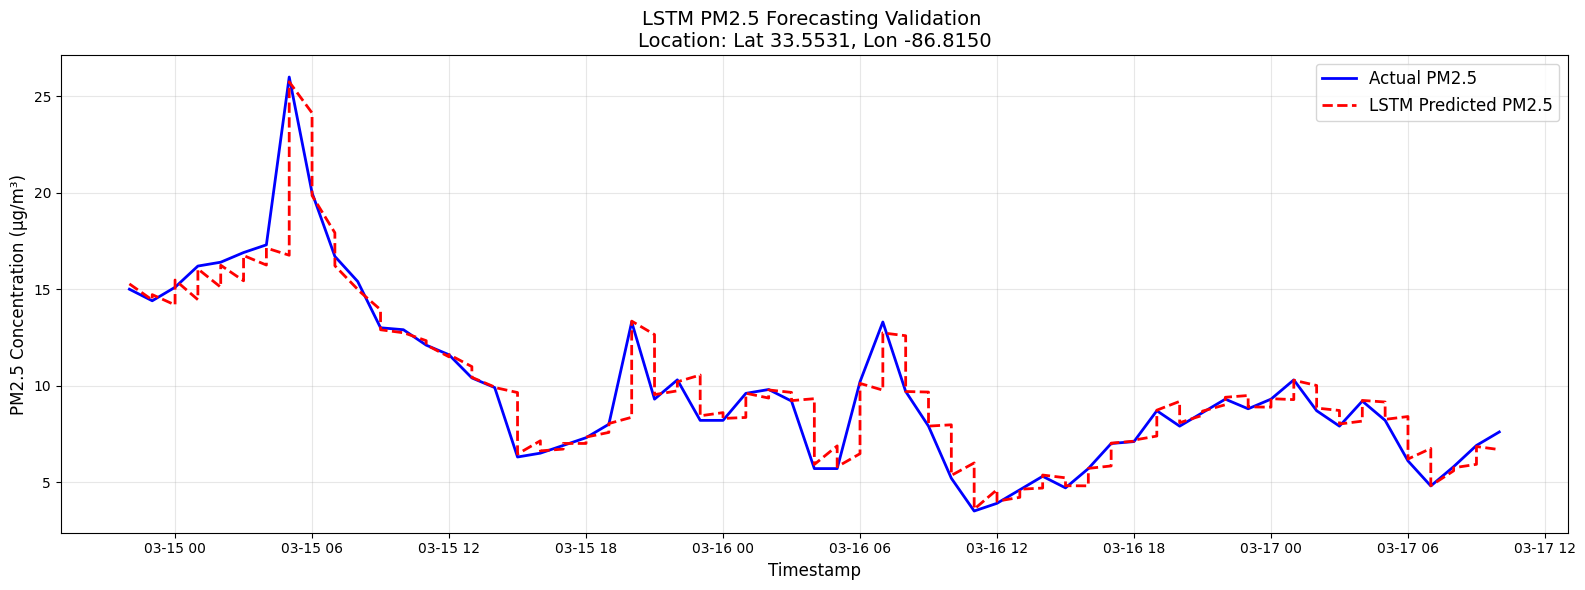

In [39]:
# predictions
y_pred_scaled = loaded_model.predict(X_val_seq)

# Inverse Transform to Real-World Units
y_pred_actual = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true_actual = scaler_y.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()

plt.figure(figsize=(16, 6))

# first 200 hours
plot_slice = 120

plt.plot(val_timestamps[:plot_slice], y_true_actual[:plot_slice], label='Actual PM2.5', color='blue', linewidth=2)
plt.plot(val_timestamps[:plot_slice], y_pred_actual[:plot_slice], label='LSTM Predicted PM2.5', color='red', linestyle='--', linewidth=2)

plt.title(f'LSTM PM2.5 Forecasting Validation \nLocation: Lat {target_lat:.4f}, Lon {target_lon:.4f}', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [59]:
def find_reliable_sensor_sites(client, year):
    print(f"Scanning EPA database for sites with all 3 sensors in {year}...")
    
    diagnostic_query = f"""
    SELECT
        pm.state_code,
        pm.county_code,
        pm.site_num,
        COUNT(*) AS concurrent_hours
    FROM
        `bigquery-public-data.epa_historical_air_quality.pm25_frm_hourly_summary` AS pm
    INNER JOIN
        `bigquery-public-data.epa_historical_air_quality.temperature_hourly_summary` AS t
        ON pm.state_code = t.state_code
        AND pm.county_code = t.county_code
        AND pm.site_num = t.site_num
        AND pm.date_local = t.date_local
        AND pm.time_local = t.time_local
    INNER JOIN
        `bigquery-public-data.epa_historical_air_quality.wind_hourly_summary` AS w
        ON pm.state_code = w.state_code
        AND pm.county_code = w.county_code
        AND pm.site_num = w.site_num
        AND pm.date_local = w.date_local
        AND pm.time_local = w.time_local
    WHERE
        pm.date_local >= '{year}-01-01'
        AND pm.date_local <= '{year}-12-31'
    GROUP BY
        pm.state_code,
        pm.county_code,
        pm.site_num
    ORDER BY
        concurrent_hours DESC
    LIMIT 10;
    """
    
    query_job = client.query(diagnostic_query)
    best_sites_df = query_job.to_dataframe()
    
    return best_sites_df


reliable_sites = find_reliable_sensor_sites(client, year='2023')
display(reliable_sites)

Scanning EPA database for sites with all 3 sensors in 2023...


,state_code,county_code,site_num,concurrent_hours
0,19,163,0015,11380
1,19,045,0019,11228
2,19,113,0040,10902
3,19,153,0030,10808
4,19,103,2001,10740
5,38,057,0004,7034
6,23,009,0103,5558
7,06,111,2002,5032
8,38,053,0002,4302
9,37,119,0041,4292


Querying EPA BigQuery from 2024-06-30 17:00:00 to 2024-07-11 00:00:00...


/usr/local/lib/python3.12/dist-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Retrieved 988 records. Processing time-series gaps...
Executing recursive forecast for 241 hours...
--- 10-Day Recursive Window Evaluation ---
Location: State 19, County 163, Site 0015
Period: 2024-07-01 to 2024-07-11
Window MAE:  3.55 µg/m³
Window RMSE: 5.68 µg/m³


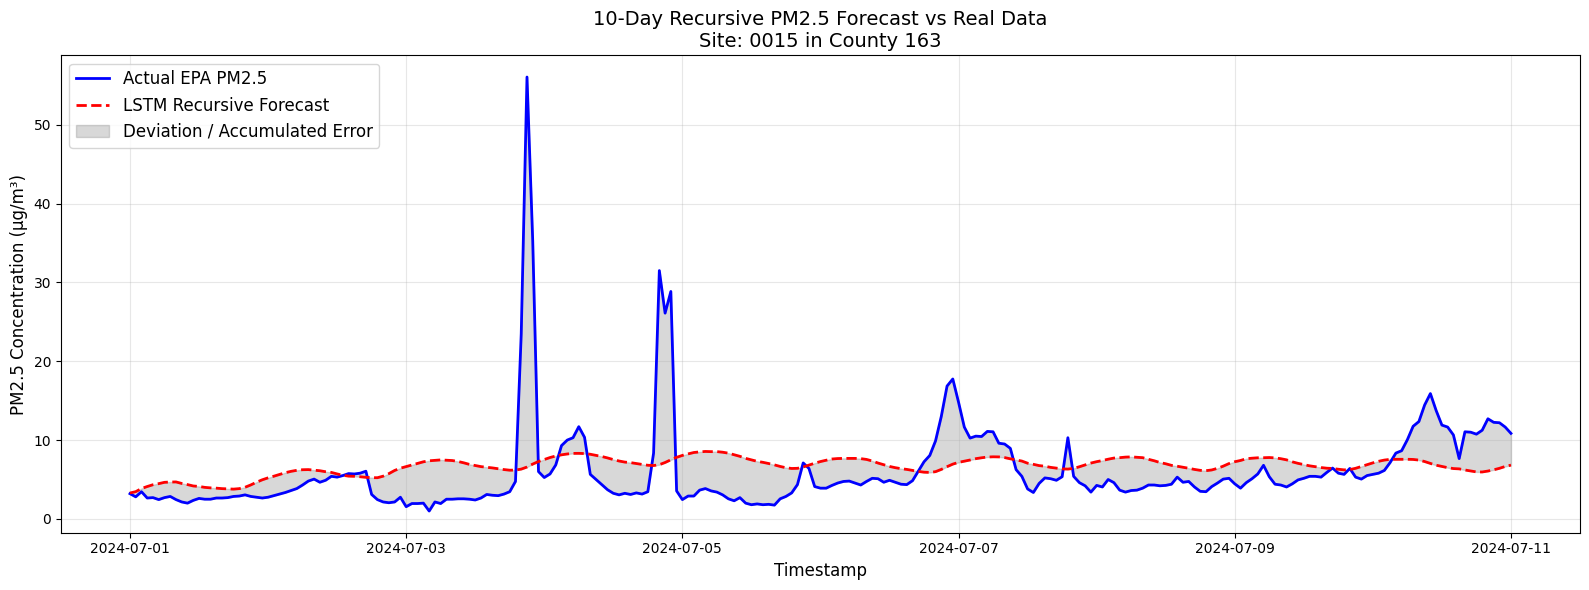

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.cloud import bigquery
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_epa_recursive_multi_day(client, model, scaler_x, scaler_y, state_code, county_code, site_num, start_date, days=14):
    """
    Performs a closed-loop recursive forecast over a multi-day window using EPA data.
    The model predicts step t+1, and that prediction is fed back into the sequence 
    to predict step t+2, flying blind on PM2.5 but using true future weather.
    """
    # 1. Define the exact time window
    start_time = pd.to_datetime(start_date)
    end_time = start_time + pd.Timedelta(days=days)
    
    # We require exactly 7 true historical hours to seed the first prediction
    buffer_time = start_time - pd.Timedelta(hours=7) 
    
    print(f"Querying EPA BigQuery from {buffer_time} to {end_time}...")
    
    # 2. Configure parameterized query
    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("state_code", "STRING", state_code),
            bigquery.ScalarQueryParameter("county_code", "STRING", county_code),
            bigquery.ScalarQueryParameter("site_num", "STRING", site_num),
            bigquery.ScalarQueryParameter("buffer_time", "TIMESTAMP", buffer_time),
            bigquery.ScalarQueryParameter("end_time", "TIMESTAMP", end_time),
        ]
    )
    
    # 3. SQL Query with strict timestamp parsing
    query = """
    WITH raw_epa_data AS (
        SELECT
            PARSE_TIMESTAMP('%Y-%m-%d %H:%M', CONCAT(CAST(pm.date_local AS STRING), ' ', pm.time_local)) AS timestamp,
            pm.latitude,
            pm.longitude,
            pm.sample_measurement AS pm25_level,
            t.sample_measurement AS temperature,
            w.sample_measurement AS wind_speed
        FROM
            `bigquery-public-data.epa_historical_air_quality.pm25_frm_hourly_summary` AS pm
        INNER JOIN
            `bigquery-public-data.epa_historical_air_quality.temperature_hourly_summary` AS t
            ON pm.state_code = t.state_code
            AND pm.county_code = t.county_code
            AND pm.site_num = t.site_num
            AND pm.date_local = t.date_local
            AND pm.time_local = t.time_local
        INNER JOIN
            `bigquery-public-data.epa_historical_air_quality.wind_hourly_summary` AS w
            ON pm.state_code = w.state_code
            AND pm.county_code = w.county_code
            AND pm.site_num = w.site_num
            AND pm.date_local = w.date_local
            AND pm.time_local = w.time_local
        WHERE
            pm.state_code = @state_code
            AND pm.county_code = @county_code
            AND pm.site_num = @site_num
    )
    SELECT * FROM raw_epa_data
    WHERE timestamp >= @buffer_time AND timestamp <= @end_time
    ORDER BY timestamp ASC;
    """
    
    query_job = client.query(query, job_config=job_config)
    epa_df = query_job.to_dataframe()
    
    if epa_df.empty:
        print("Error: No intersecting data found for PM2.5, Temperature, and Wind at this location/time.")
        return
        
    print(f"Retrieved {len(epa_df)} records. Processing time-series gaps...")
    
    # strict 1-hour intervals 
    # avg duplicate hours (multiple sensors/POCs), then resample and forward-fill gaps
    epa_df = epa_df.groupby('timestamp').mean().reset_index()
    epa_df = epa_df.set_index('timestamp').resample('h').ffill().reset_index()
    
    # 5. Extract cyclical features for the clean timeline
    DAYS_IN_YEAR = 365.2425
    HOURS_IN_DAY = 24.0
    day_of_year = epa_df['timestamp'].dt.dayofyear
    hour_of_day = epa_df['timestamp'].dt.hour
    
    epa_df['day_sin'] = np.sin(2 * np.pi * day_of_year / DAYS_IN_YEAR)
    epa_df['day_cos'] = np.cos(2 * np.pi * day_of_year / DAYS_IN_YEAR)
    epa_df['hour_sin'] = np.sin(2 * np.pi * hour_of_day / HOURS_IN_DAY)
    epa_df['hour_cos'] = np.cos(2 * np.pi * hour_of_day / HOURS_IN_DAY)
    
    lstm_features = ['pm25_level', 'latitude', 'longitude', 'temperature', 'wind_speed', 'day_sin', 'day_cos', 'hour_sin', 'hour_cos']
    
    scaled_features = scaler_x.transform(epa_df[lstm_features])
    
    sequence_length = 7
    
    current_sequence = scaled_features[0:sequence_length].copy()
    
    predictions_scaled = []
    y_true_scaled = []
    timestamps = []
    
    print(f"Executing recursive forecast for {len(scaled_features) - sequence_length} hours...")
    
    # 8. Loop through the remaining hours
    for i in range(sequence_length, len(scaled_features)):
        # Reshape current sequence for LSTM input (1 sample, 7 timesteps, 9 features)
        lstm_input = current_sequence.reshape(1, sequence_length, 9)
        
        # Predict the next hour's PM2.5 (outputs a scaled value)
        next_pm25_scaled = model.predict(lstm_input, verbose=0)[0][0]
        
        predictions_scaled.append(next_pm25_scaled)
        
        # Log the true target and timestamp for evaluation
        y_true_scaled.append(scaled_features[i][0])
        timestamps.append(epa_df['timestamp'].iloc[i])
        
        # TRUE weather/time features for hour 'i'
        # overwrite the PM2.5 feature (index 0) using SYNTHESIZED prediction.
        next_step_features = scaled_features[i].copy()
        next_step_features[0] = next_pm25_scaled 
        
        # Slide the window forward: drop the oldest row, append the synthesized row
        current_sequence = np.vstack([current_sequence[1:], next_step_features])
        
    y_true_scaled = np.array(y_true_scaled).reshape(-1, 1)
    predictions_scaled = np.array(predictions_scaled).reshape(-1, 1)
    
    # Inverse Transform back to real-world µg/m³
    y_pred_actual = scaler_y.inverse_transform(predictions_scaled).flatten()
    y_true_actual = scaler_y.inverse_transform(y_true_scaled).flatten()
    
    # plot
    mae = mean_absolute_error(y_true_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
    
    print(f"--- {days}-Day Recursive Window Evaluation ---")
    print(f"Location: State {state_code}, County {county_code}, Site {site_num}")
    print(f"Period: {start_time.date()} to {end_time.date()}")
    print(f"Window MAE:  {mae:.2f} µg/m³")
    print(f"Window RMSE: {rmse:.2f} µg/m³")
    
    plt.figure(figsize=(16, 6))
    plt.plot(timestamps, y_true_actual, label='Actual EPA PM2.5', color='blue', linewidth=2)
    plt.plot(timestamps, y_pred_actual, label='LSTM Recursive Forecast', color='red', linestyle='--', linewidth=2)
    
    plt.fill_between(timestamps, y_true_actual, y_pred_actual, color='gray', alpha=0.3, label='Deviation / Accumulated Error')
    
    plt.title(f'{days}-Day Recursive PM2.5 Forecast vs Real Data\nSite: {site_num} in County {county_code}', fontsize=14)
    plt.xlabel('Timestamp', fontsize=12)
    plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=12)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

target_start = '2024-07-01 00:00:00' # Example start date

evaluate_epa_recursive_multi_day(
    client=bq_client,
    model=loaded_model,
    scaler_x=scaler_x,       
    scaler_y=scaler_y,       
    state_code='19',         
    county_code='163',       
    site_num='0015',         # Specific site
    start_date=target_start,
    days=10                  #
 )

Querying EPA BigQuery from 2024-07-04 14:00:00 to 2024-07-14 21:00:00...


/usr/local/lib/python3.12/dist-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Retrieved 992 records. Processing time-series gaps...
Executing recursive forecast for 241 hours...
--- 10-Day Recursive Window Evaluation ---
Location: State 19, County 163, Site 0015
Period: 2024-07-04 to 2024-07-14
Window MAE:  4.58 µg/m³
Window RMSE: 7.34 µg/m³


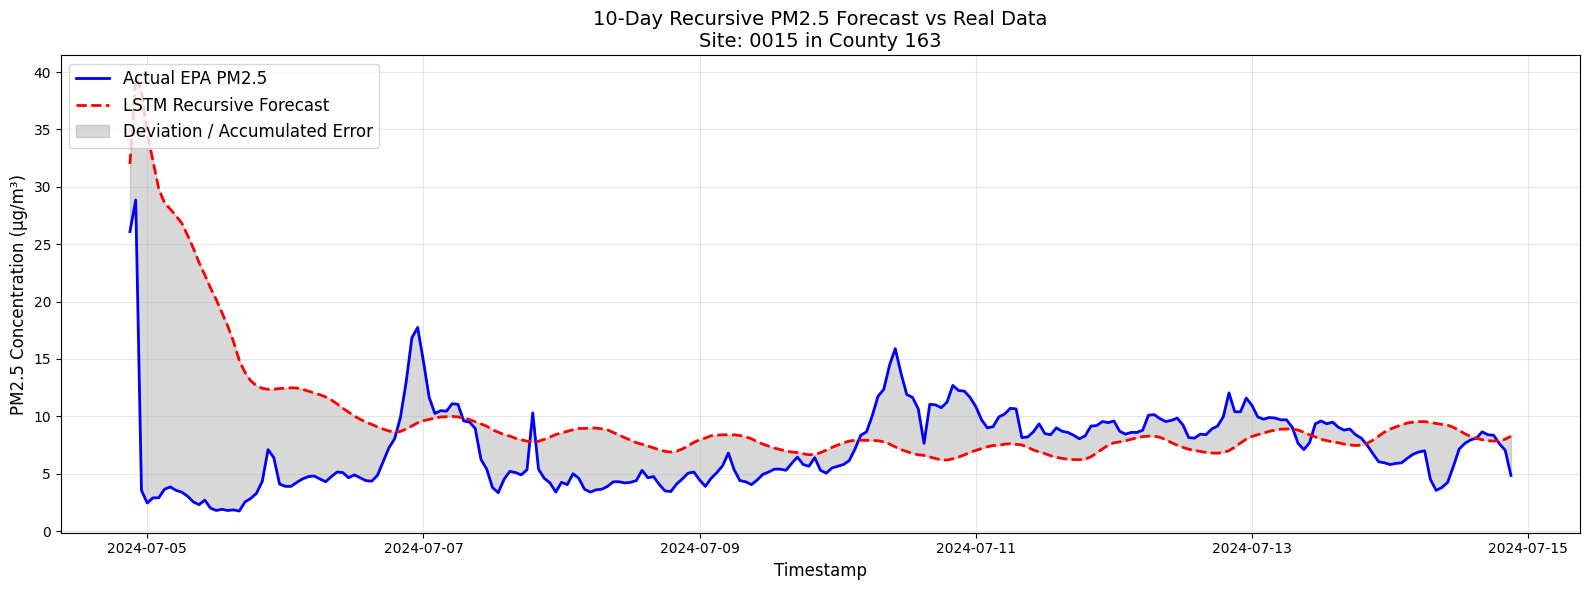

In [67]:
target_start = '2024-07-04 21:00:00'

evaluate_epa_recursive_multi_day(
    client=bq_client,
    model=loaded_model,
    scaler_x=scaler_x,       
    scaler_y=scaler_y,       
    state_code='19',         
    county_code='163',       
    site_num='0015',         # Specific site
    start_date=target_start,
    days=10                  #
 )